<a href="https://colab.research.google.com/github/nasyafauziah/Indobert_withprepo/blob/main/indobert_prepocessing_stopwordremoval_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data = pd.read_csv("/content/data_preprocessing_withstopwordromoval.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   full_text     1997 non-null   object
 1   cleaning      1997 non-null   object
 2   case_folding  1997 non-null   object
 3   normalisasi   1997 non-null   object
 4   text_final    1997 non-null   object
dtypes: object(5)
memory usage: 78.1+ KB


In [ ]:
data.head(5)

,full_text,cleaning,case_folding,normalisasi,text_final
0,@PartaiSocmed @Heraloebss Tanpa sebab? Sebabny...,Tanpa sebab Sebabnya seruan bubarkan dpr aga...,tanpa sebab sebabnya seruan bubarkan dpr aga...,tanpa sebab sebabnya seruan bubarkan dpr agar ...,tanpa seruan bubarkan dpr maksulkan gibran tak...
1,Sebab MBG adalah salah satu instrument politik...,Sebab MBG adalah salah satu instrument politik...,sebab mbg adalah salah satu instrument politik...,sebab mbak adalah salah satu instrument politi...,mbak salah instrument politik genk solo sontol...
2,Kl mau fair hrsnya yg menggaungkan hashtag bub...,Kl mau fair hrsnya yg menggaungkan hashtag bub...,kl mau fair hrsnya yg menggaungkan hashtag bub...,kalau mau fair harusnya yang menggaungkan hash...,fair menggaungkan hashtag bubarkan dpr kemarin...
3,@Andria75777 Bubarkan DPR,Bubarkan DPR,bubarkan dpr,bubarkan dpr,bubarkan dpr
4,dia yang hadiri kumpul2 di banyuwangi dgn eks ...,dia yang hadiri kumpul di banyuwangi dgn eks P...,dia yang hadiri kumpul di banyuwangi dgn eks p...,dia yang hadiri kumpul di banyuwangi dengan ek...,hadiri kumpul banyuwangi eks pki


In [ ]:
df  = pd.DataFrame(data[['text_final']])
df.head(5)

,text_final
0,tanpa seruan bubarkan dpr maksulkan gibran tak...
1,mbak salah instrument politik genk solo sontol...
2,fair menggaungkan hashtag bubarkan dpr kemarin...
3,bubarkan dpr
4,hadiri kumpul banyuwangi eks pki


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text_final  1997 non-null   object
dtypes: object(1)
memory usage: 15.7+ KB


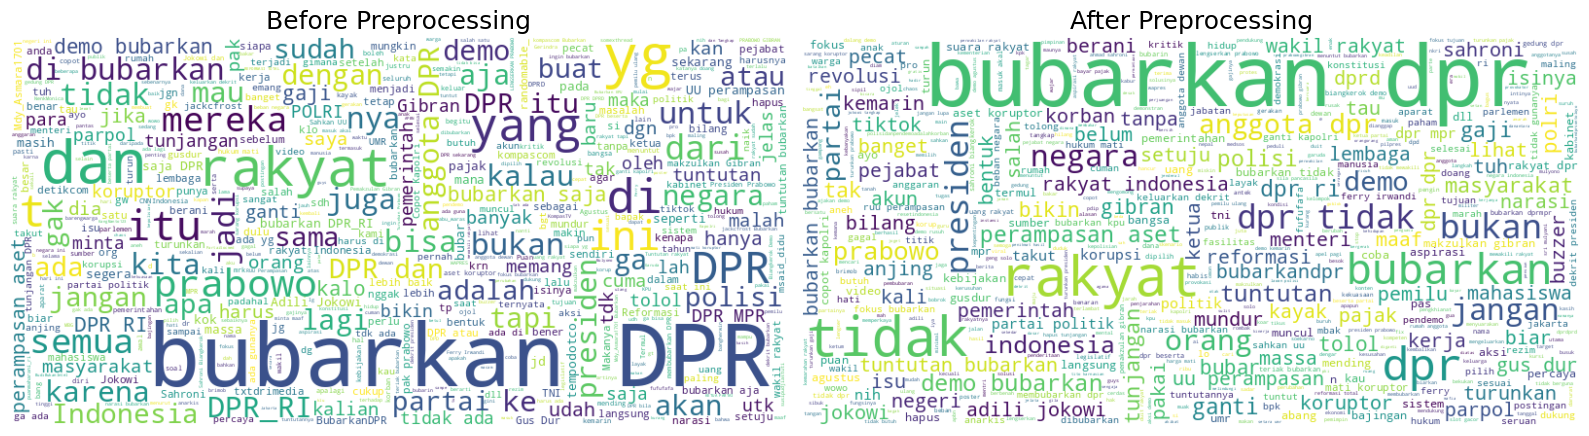

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih','update','apk'])

# WordCloud Before (dari kolom 'Review Text')
text_before = ' '.join(data['full_text'].astype(str).tolist())
wc_before = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400).generate(text_before)

# WordCloud After (dari kolom 'steming_data')
text_after = ' '.join(data['text_final'].astype(str).tolist())
wc_after = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400).generate(text_after)

# Visualisasi side-by-side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Before Preprocessing", fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("After Preprocessing", fontsize=18)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        sentiment = "Negatif" if sentiment_score <= 0 else "Positif"
        return sentiment_score, sentiment
    return 0, "Negatif"

df[['Score', 'Sentiment']] = df['text_final'].apply(lambda x: pd.Series(determine_sentiment(x)))
df.head(5)


,text_final,Score,Sentiment
0,tanpa seruan bubarkan dpr maksulkan gibran tak...,2,Positif
1,mbak salah instrument politik genk solo sontol...,0,Negatif
2,fair menggaungkan hashtag bubarkan dpr kemarin...,-1,Negatif
3,bubarkan dpr,0,Negatif
4,hadiri kumpul banyuwangi eks pki,-1,Negatif


/tmp/ipykernel_12928/1334170187.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


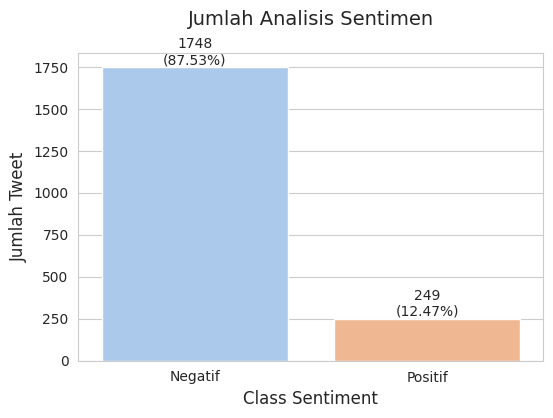

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = df['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

total = len(df['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [ ]:
df.to_csv('Hasil_Labelling_Data.csv',encoding='utf8', index=False)

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data.csv")
data.head(5)

,text_final,Score,Sentiment
0,tanpa seruan bubarkan dpr maksulkan gibran tak...,2,Positif
1,mbak salah instrument politik genk solo sontol...,0,Negatif
2,fair menggaungkan hashtag bubarkan dpr kemarin...,-1,Negatif
3,bubarkan dpr,0,Negatif
4,hadiri kumpul banyuwangi eks pki,-1,Negatif


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text_final  1997 non-null   object
 1   Score       1997 non-null   int64 
 2   Sentiment   1997 non-null   object
dtypes: int64(1), object(2)
memory usage: 46.9+ KB


In [ ]:
data = pd.DataFrame(data[['text_final','Sentiment']])
data.head(25)

,text_final,Sentiment
0,tanpa seruan bubarkan dpr maksulkan gibran tak...,Positif
1,mbak salah instrument politik genk solo sontol...,Negatif
2,fair menggaungkan hashtag bubarkan dpr kemarin...,Negatif
3,bubarkan dpr,Negatif
4,hadiri kumpul banyuwangi eks pki,Negatif
5,bubarkan polri pilihan terbaik tak repotrepot ...,Positif
6,gas bubarkan polri tidak repot ganti polri per...,Negatif
7,tidak demo bubarkan dpr kasih gaji umr bubar,Negatif
8,analisa ferry irwandi masuk akal akun provokas...,Negatif
9,lengserkan ya dpr bubarkan bangsa hancur pemil...,Negatif


In [ ]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 83.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install transformers datasets scikit-learn seaborn matplotlib

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset

# Load data
df = pd.read_csv("Hasil_Labelling_Data.csv")

df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text_final  1997 non-null   object
 1   Score       1997 non-null   int64 
 2   Sentiment   1997 non-null   object
dtypes: int64(1), object(2)
memory usage: 46.9+ KB


,text_final,Score,Sentiment
0,tanpa seruan bubarkan dpr maksulkan gibran tak...,2,Positif
1,mbak salah instrument politik genk solo sontol...,0,Negatif
2,fair menggaungkan hashtag bubarkan dpr kemarin...,-1,Negatif
3,bubarkan dpr,0,Negatif
4,hadiri kumpul banyuwangi eks pki,-1,Negatif


In [ ]:
# Encode label jika belum numerik
if df['Sentiment'].dtype == 'object':
    df['Sentiment'] = df['Sentiment'].astype('category').cat.codes

# Split data 80:20
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
# Tokenizer IndoBERT
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize_function(example):
    return {
        **tokenizer(example["text_final"], truncation=True),
        'labels': example['Sentiment']
    }

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1597 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [ ]:
# Update Training arguments untuk mencoba meningkatkan recall
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16, # Batch size sedikit diperbesar
    per_device_eval_batch_size=16,
    num_train_epochs=5,             # Ditambah dari 3 ke 5 agar model belajar lebih dalam
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Hyperparameters telah diperbarui untuk meningkatkan performa.")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Define compute metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
    }

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
# Train
trainer.train()

#  Evaluate
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true = predictions.label_ids

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.331357,0.877500
2,No log,0.321476,0.892500
3,0.290658,0.483274,0.882500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.8925

Classification Report:
               precision    recall  f1-score   support

     Positif       0.91      0.97      0.94       340
     Negatif       0.73      0.45      0.56        60

    accuracy                           0.89       400
   macro avg       0.82      0.71      0.75       400
weighted avg       0.88      0.89      0.88       400



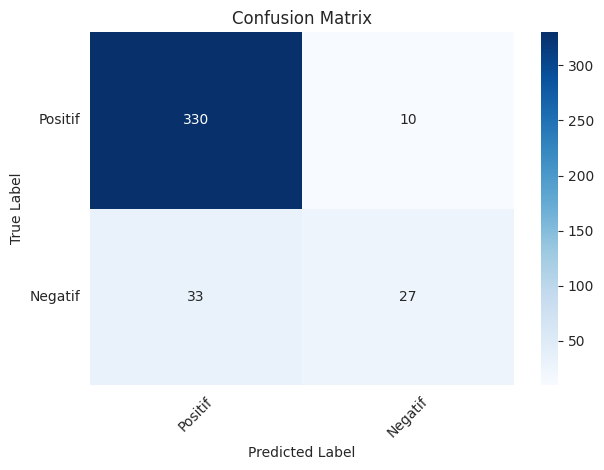

In [ ]:
from sklearn.utils.multiclass import unique_labels

# Semua label sentimen sesuai grafik Anda
all_label_names = ['Positif', 'Negatif']

# Ambil label yang benar-benar ada di hasil prediksi
labels_in_data = sorted(list(unique_labels(true, preds)))
used_label_names = [all_label_names[i] for i in labels_in_data]

# Classification report & accuracy
print("Accuracy:", accuracy_score(true, preds))
print("\nClassification Report:\n", classification_report(true, preds, target_names=used_label_names))

# Confusion Matrix
cm = confusion_matrix(true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=used_label_names, yticklabels=used_label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# 1. Pastikan data dipisah dulu (Sudah dilakukan di cell r3-NwUjr428R)
# 2. Inisialisasi RandomOverSampler
ros = RandomOverSampler(random_state=42)

# 3. Oversampling HANYA pada data training
X_train_res, y_train_res = ros.fit_resample(train_df[['text_final']], train_df['Sentiment'])

# 4. Buat DataFrame baru yang seimbang
train_df_balanced = pd.DataFrame({
    'text_final': X_train_res['text_final'],
    'Sentiment': y_train_res
})

print("Distribusi Label Sebelum Oversampling:")
print(train_df['Sentiment'].value_counts())
print("\nDistribusi Label Setelah Oversampling:")
print(train_df_balanced['Sentiment'].value_counts())

# Preview data baru
display(train_df_balanced.head())

Distribusi Label Sebelum Oversampling:
Sentiment
0    1408
1     189
Name: count, dtype: int64

Distribusi Label Setelah Oversampling:
Sentiment
0    1408
1    1408
Name: count, dtype: int64


,text_final,Sentiment
0,indonesia baiksatunya jalan reset membubarkan ...,0
1,semoga indonesia cepat sembuh dpr bubarkan pem...,0
2,bubarkan dpr pengin wowo diktator paham trias ...,0
3,bubarkan dpr waspada anjing termul,0
4,loh jokowi blog tuntutannya bubarkan dpr sahka...,0


### Retokenization with Balanced Data
Sekarang kita perlu memetakan ulang dataset Hugging Face menggunakan data training yang sudah seimbang.

In [ ]:
from datasets import Dataset

# Convert balanced dataframe to Hugging Face Dataset
train_dataset_balanced = Dataset.from_pandas(train_df_balanced)

# Tokenize ulang data training yang baru
train_dataset_balanced = train_dataset_balanced.map(tokenize_function, batched=True)

print("Data training seimbang siap digunakan untuk training ulang.")

Map:   0%|          | 0/2816 [00:00<?, ? examples/s]

Data training seimbang siap digunakan untuk training ulang.


In [ ]:
# Jalankan ulang training dengan parameter baru
model = BertForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=2)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_balanced,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Memulai training ulang dengan 5 Epochs...")
trainer.train()

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Memulai training ulang dengan data seimbang...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.612827,0.867500
2,0.262499,0.946472,0.865000
3,0.014806,0.990292,0.867500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1056, training_loss=0.13133315847495175, metrics={'train_runtime': 4274.1034, 'train_samples_per_second': 1.977, 'train_steps_per_second': 0.247, 'total_flos': 152834634282240.0, 'train_loss': 0.13133315847495175, 'epoch': 3.0})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy After Oversampling: 0.8675

Classification Report:
               precision    recall  f1-score   support

     Negatif       0.92      0.93      0.92       340
     Positif       0.56      0.52      0.54        60

    accuracy                           0.87       400
   macro avg       0.74      0.72      0.73       400
weighted avg       0.86      0.87      0.87       400



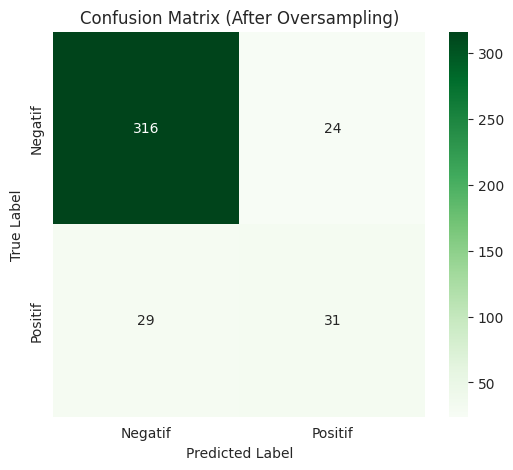

In [ ]:
# 3. Evaluasi Akhir
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true = predictions.label_ids

# Cetak Classification Report
all_label_names = ['Negatif', 'Positif'] # Sesuai mapping cat.codes
print("Accuracy After Oversampling:", accuracy_score(true, preds))
print("\nClassification Report:\n", classification_report(true, preds, target_names=all_label_names))

# Visualisasi Confusion Matrix Baru
plt.figure(figsize=(6, 5))
cm = confusion_matrix(true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=all_label_names, yticklabels=all_label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (After Oversampling)')
plt.show()